#Trabajo Práctico Módulo 2 - Detección de Transacciones Fraudulentas

Para la resolución de este trabajo se eligió el siguiente problema:

Una compañía de crédito está harta de que sus clientes reporten transacciones financieras como fraudulentas. Por ello, decidió contratarnos para que generemos una herramienta capaz de detectar comportamientos extraños en los consumos, que nos permitan evitar que los usuarios le hagan pagar transacciones que en realidad son correctas. Para ello, reunió este conjunto de datos, en donde las operaciones fueron enmascaradas en características para proteger la identidad de los usuarios.

*Integrantes: Machini Ariel, Herrero Juan Francisco y Ferrero Martino*


# Instalación de librerías y dependencias

In [ ]:
! pip install ydata-profiling
# ! pip install kaggle

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=420ed85b248a5ad1de075f7d2027792612102f815a0514a5db3a8dd64165ba94
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


# Importando librerías necesarias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from ydata_profiling import ProfileReport
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score as f1s, recall_score as rs, precision_score as ps

# Descarga del dataset de consumos en tarjetas de crédito

In [ ]:
! curl -L -o /content/sample_data/credit_card.zip https://www.kaggle.com/api/v1/datasets/download/mlg-ulb/creditcardfraud

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 65.9M  100 65.9M    0     0  88.3M      0 --:--:-- --:--:-- --:--:--  194M


In [ ]:
!unzip -q ./sample_data/credit_card.zip

!ls

creditcard.csv	sample_data


In [ ]:
credit_card_df = pd.read_csv('./creditcard.csv')

# Análisis del dataset

Durante el análisis del dataset se pudo observar distintas cuestiones:

- Existen un total de 31 columnas en el dataset, de las cuales una corresponda a la clase (con valores 0 o 1), 28 son el resultado de haber aplicado previamente PCA a columnas originales (lo cual tiene sentido ya que se trata de datos muy importantes y que deben ser cuidados, además de que reduce la dimensionalidad), otra está asociada al tiempo medido en segundos (y correspondiente a un plazo de 2 días) y finalmente hay una que indica el monto de la transacción.
- Hay una proporción extremedamante más alta de muestras de la clase 0 que de la clase 1, lo que determina claramente que se trata de un problema de detección de anomalías.
- No se puede ver grandes correlaciones entre las columnas a las que se les aplicó PCA y las demás, y esto tiene sentido porque la información de correlación que probablemente tienen las features originales desde V1 a V28 están ocultas por el PCA.
- No hay valores faltantes, lo que resulta una gran ventaja a la hora del entrenamiento ya que no es necesario la eliminación de filas por ese motivo ni de tener que aplicar técnicas de imputing de datos.
- El monto y el tiempo tienen poca correlación, pero el monto en sí es la feature que más correlacionada está con las demás. Por su parte el tiempo tiene un cierto grado de correlación negativo y otras positivas con algunas features, pero no en tanta medida como el monto.
- Una vez que se estandarizó el tiempo a horas de un mismo día, se pudo observar que la frecuencia de anomalías tiene mayor significancia a ciertos horarios, y en especial a la hora 2 y la hora 11 respecto a la hora inicio, que contienen la mayor parte de las muestras anómalas. Sin embargo, aunque tienen una cantidad similar de anomalías, la hora 2 tiene una relación mucho mayor de muestras de este tipo sobre el total de muestras para esa misma hora, que en el caso de la 11. Esto ocurre porque probablemente la hora 11 representa un momento del día muy popular para las transacciones, lo que se evidencia en el gráfico de la distribución total de muestras por hora del día. A su vez, este último gráfico es practicamente indistinguible del de muestras no anómalas y esto tiene sentido por el elevado porcentaje de las mismas en el dataset.
- Muchas de las features reducidas con PCA siguen una distribución relativamente normal gaussiana. Esto favorece al entrenamiento, y tiene particular sentido en las features reducidas con PCA puesto que en general antes de esta técnica se suele estandarizar los datos lo cual contribuye a esto, colocando la media en 0 y la desviación en 1.
- A priori no pareciera haber grandes outliers de muestras, otro punto a favor para el entrenamiento.

## Análisis sobre el total de los datos

In [ ]:
X_df_complete = credit_card_df.drop(columns='Class')
y_df_complete = credit_card_df['Class']

Se analiza el total de muestras en el dataset, y en particular la cantidad de anómalas y no anómalas. Es evidente que hay una gran cantidad de muestras, de las cuales casi la totalidad corresponde a muestras no anómalas, habiendo las siguientes relaciones:

- Muestras totales: 284807
- Muestras no anómalas: 492 (aproximadamente 0,17 %)
- Muestras anómalas: 284315 (aproximadamente 99,82 %)

Además no se observan muestras anómalas


In [ ]:
total_samples = len(credit_card_df)
total_anomalies = len(credit_card_df[y_df_complete == 1])
total_non_anomalies = len(credit_card_df[y_df_complete == 0])

print("Total de muestras: {}".format(total_samples))
print("Cantidad de muestras anomalas: {}".format(total_anomalies) + " ({} %)".format(round(total_anomalies*100/total_samples, 5)))
print("Cantidad de muestras no anomalas: {}".format(total_non_anomalies) + " ({} %)".format(round(total_non_anomalies*100/total_samples, 5)))

is_nan = credit_card_df.isnull()
row_has_nan = is_nan.any(axis=1)
rows_with_nan = credit_card_df[row_has_nan]
print("Hay {} filas con valores nulos:\n".format(len(rows_with_nan)), rows_with_nan)

Total de muestras: 284807
Cantidad de muestras anomalas: 492 (0.17275 %)
Cantidad de muestras no anomalas: 284315 (99.82725 %)
Hay 0 filas con valores nulos:
 Empty DataFrame
Columns: [Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, Class]
Index: []

[0 rows x 31 columns]


In [ ]:
credit_card_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


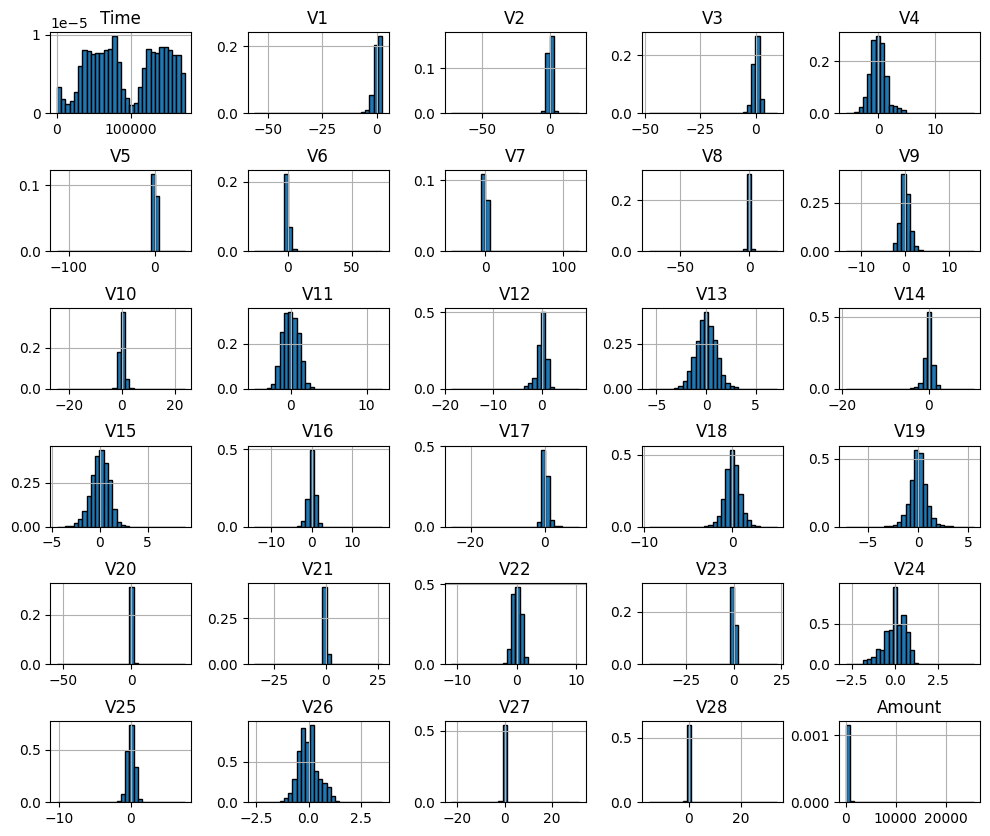

In [ ]:
X_df_complete.hist(figsize=(12, 10), bins=30, edgecolor="black", density=True)
plt.subplots_adjust(hspace=0.7, wspace=0.4)

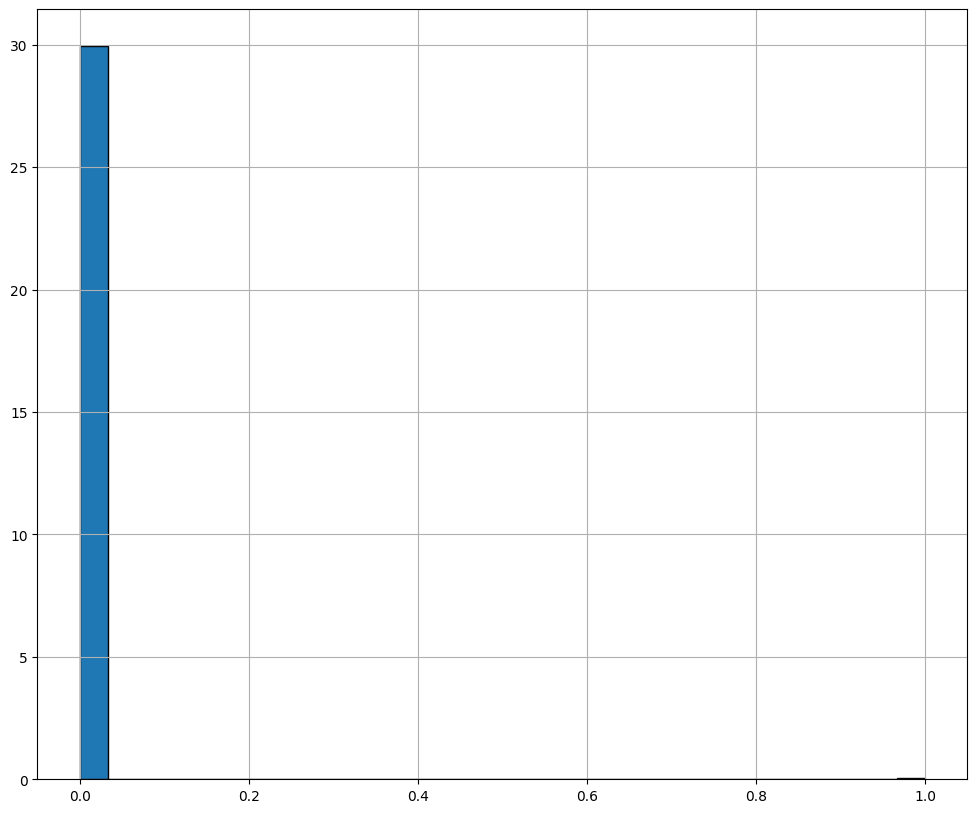

In [ ]:
y_df_complete.hist(figsize=(12, 10), bins=30, edgecolor="black", density=True)
plt.subplots_adjust(hspace=0.7, wspace=0.4)

In [ ]:
correlation_matrix_complete = X_df_complete.corr()
correlation_matrix_complete

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,-5.086602e-02,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,4.654551e-16,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,2.506675e-16,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,-9.316409e-16,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.857247e-16,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.554057e-16,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,-1.858755e-16,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,9.379684e-16,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,2.033737e-16,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,-2.343720e-16,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246


<Axes: >

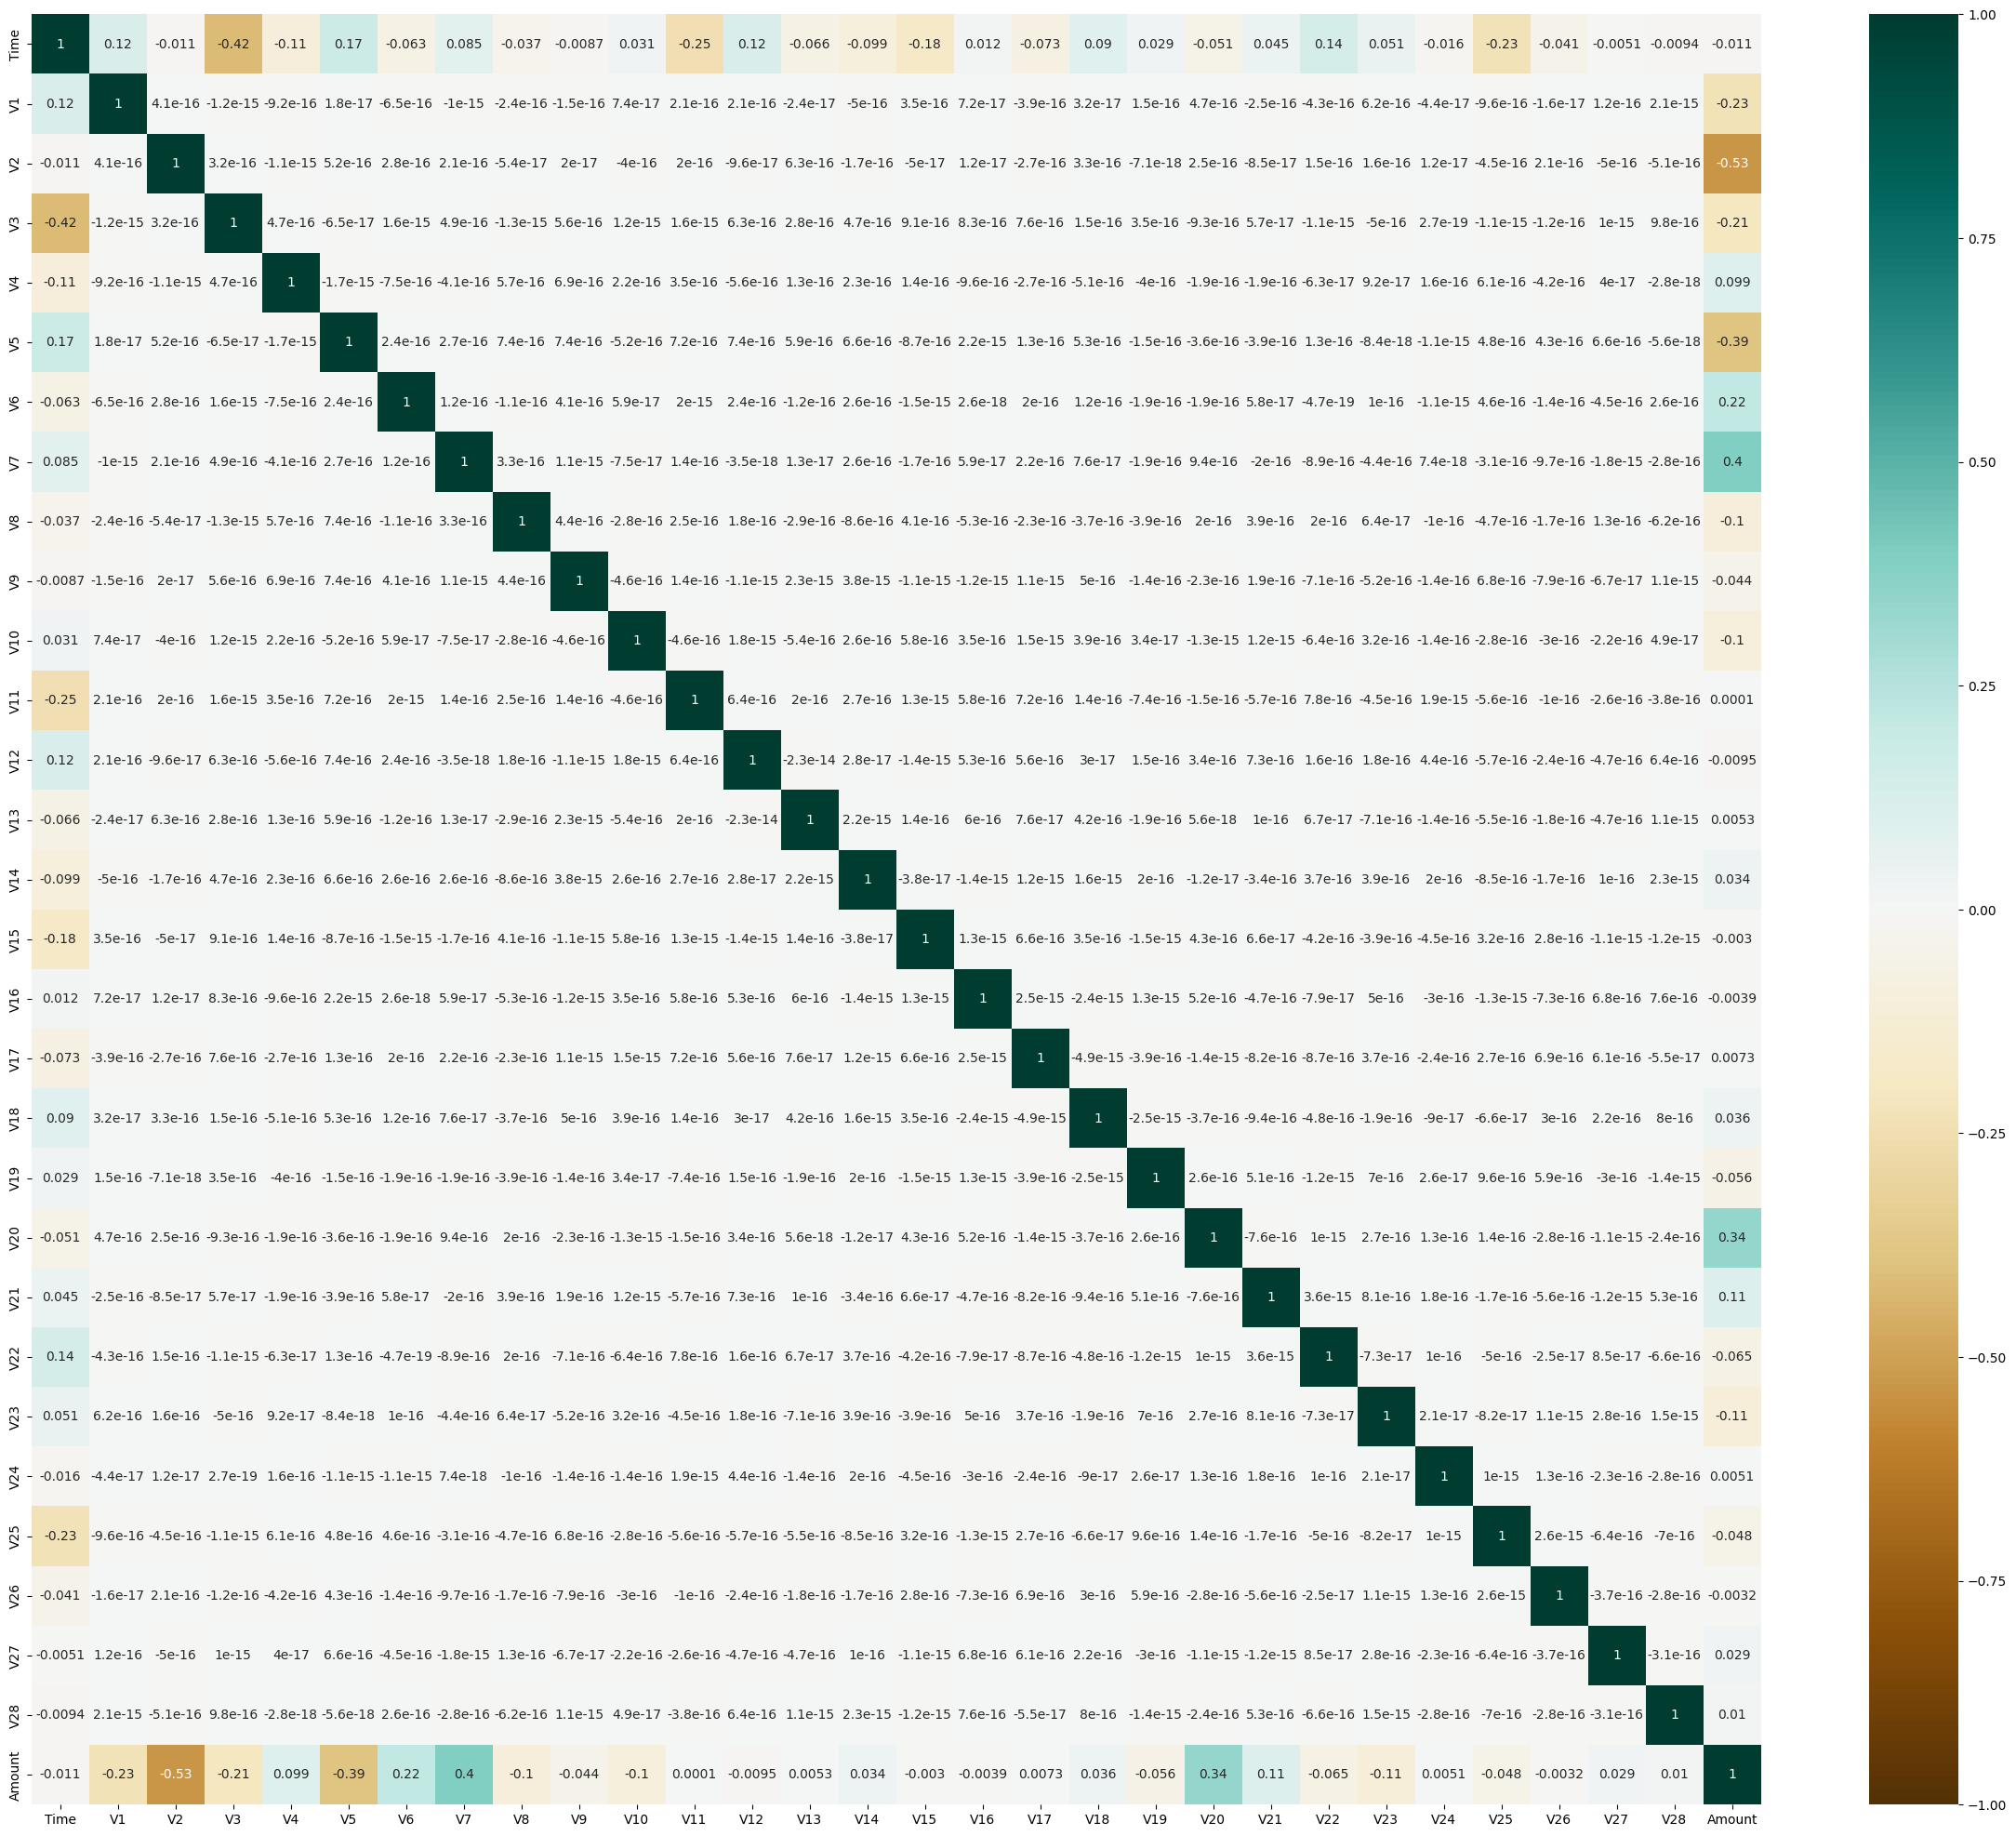

In [ ]:
plt.figure(figsize=(30,25))
sns.heatmap(correlation_matrix_complete, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap='BrBG')

### Analisis costosos utilizando todos los datos

In [ ]:
# axs = scatter_matrix(X_df_complete, figsize=(16,12), alpha=0.47, hist_kwds={'color':'#ff7f0e'});

# for i in range(len(X_df_complete.columns)):
#   for j in range(len(X_df_complete.columns)):
#     ax=axs[i,j]
#     ax.xaxis.label.set_rotation(90)
#     ax.yaxis.label.set_rotation(0)
#     ax.yaxis.label.set_ha('right')

In [ ]:
# sns.set_style("darkgrid")

# def hide_current_axis(*args, **kwds):
#     plt.gca().set_visible(False)

# iris_plot = sns.pairplot(credit_card_df, hue="Class")
# iris_plot.map_upper(hide_current_axis)
# plt.show()

In [ ]:
# profile = ProfileReport(credit_card_df)
# profile

# Tratamiento de la feature de tiempo

Dado que el tiempo estaba expresado en segundos, se analizó la cantidad de horas que representa el máximo valor de dicha columna respecto a la hora inicio, dividiéndolo por 3600. En consecuencia, se pudo ver que representa aproximadamente 48 horas, o sea 2 días. Por ende, se decidió aplicar alguna técnica para reducir la cantidad de intervalos de tiempo que representa este. Esto se pensó por dos motivos fundamentes:

- Si bien el tiempo representa un valor numérico continuo, en este caso no tiene sentido trabajarlo como una escala como sí lo es el monto, puesto que la cantidad de tiempo transcurrido no sigue una relación continua evidente con la probabilidad de que una muestra sea anómala o no (principalmente porque la distribución respecto a la variable se observó que es muy particular, con subidas y bajadas muy abruptas de la cantidad de anomalías). Esto a su vez también descartó la posibilidad de trabajarlo en base al seno y coseno del mismo, ya que la frecuencia de anomalías respecto a este no sigue ese tipo de distribución.
- Si se lo trabaja como una variable categórica, es extremadamente costoso trabajarlo como segundos y luego aplicar One Hot Encoding sobre el mismo, debido a la cantidad de categorías que podría haber (y además aun peor para la cantidad enorme de muestras que hay en el dataset).

Por ende, se plantearon dos alternativas. Trabajar el tiempo como horas transcurridas durante todas las muestras (lo que derivaría en 48 categorías) o bien horas transcurridas respecto al día en el que se posiciona en sí (lo cual representa 24 categorías). De estas dos, se tomó la segunda opción por tres razones principales:

- Dos días es muy poco tiempo. Si por ejemplo los datos correspondieran a información de un lunes y un martes, y más adelante se quiere enviar como entrada una asociada por ejemplo a un miércoles, el modelo tendría pocos recursos para trabajar el mismo, que sería considerado probablemente un outlier en cuanto a tiempo y por ende se lo inclinaría a ser una anomalía sin realmente tener por qué serlo desde un punto de vista lógico. Además el usuario tendría que tener en cuenta la hora relativa a la hora inicio de los datos utilizados para entrenar el modelo, lo cual sería muy impracticable.
- En general desde el sentido común se puede asumir que no hay una diferencia significativa entre dos mismas horas de días diferentes. Esto se comprueba en el análisis de la distribución de los datos donde se puede ver que las dos mitades del gráfico son prácticamente iguales, lo que da la idea de que las muestras se distribuyen similar para las mismas horas de días distintos.
- Teniendo en cuenta todo esto, y que realmente no se pierde información representando las muestras por horas de un mismo día en comparación con horas de todo el periodo, es lógicamente más eficiente y menos costoso para el entrenamiento trabajar el tiempo en 24 categorías menos.

Se consideró la alternativa de trabajar el tiempo reduciendo aun más las categorías del mismo, agrupando por baldes las horas en relación a la frecuencia de anomalías que poseían sobre el total de muestras para esas mismas horas, agrupando de manera conjunta a las que tengan frecuencias similares (de esta manera, no se tiene en cuenta solo la cantidad de anomalías por hora sino su relación respecto al total para esa hora, porque puede haber muchas anomalías en una hora muy frecuente como en la hora 11 sin tener el mismo peso que las de la hora 2). Sin embargo esto último no se hizo puesto que se consideró que era suficiente con la reducción ya realizada, y en las pruebas se evidenció que el downsampling que se llevó a cabo era suficiente para obtener resultados aceptables (de lo contrario se habría evaluado más esta alternativa para reducir aun más la cantidad de categorías para luego tener que aplicar un downsampling menos brusco).

In [ ]:
print("Cantidad de horas transcurridas desde el inicio: {}".format(np.max(credit_card_df['Time']/3600)))

Cantidad de horas transcurridas desde el inicio: 47.99777777777778


In [ ]:
credit_card_df['Time'] = credit_card_df['Time'] % 86400

credit_card_df['Time'] = (credit_card_df['Time'] // 3600).astype(int)

In [ ]:
X_df_complete = credit_card_df.drop(columns='Class')
y_df_complete = credit_card_df['Class']

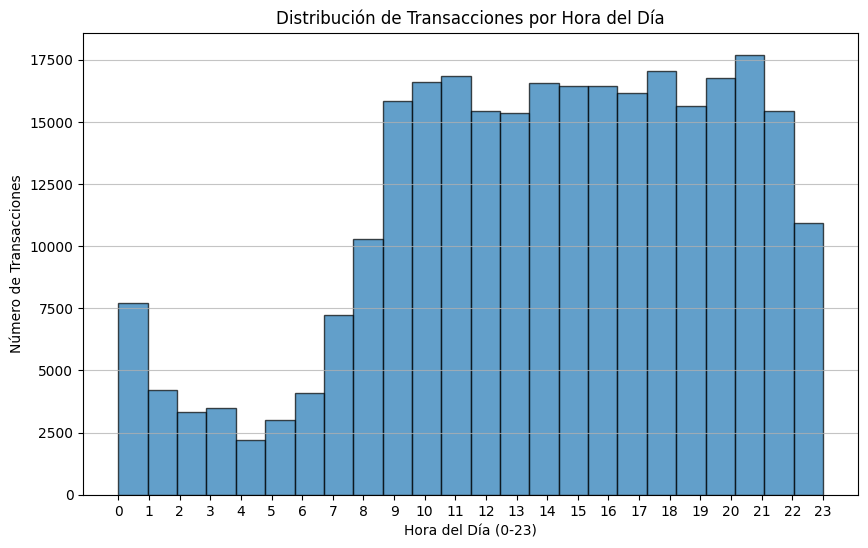

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(credit_card_df['Time'], bins=24, edgecolor='black', alpha=0.7)

plt.title('Distribución de Transacciones por Hora del Día')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Número de Transacciones')
plt.xticks(range(0, 24))

plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
anomalies_time_complete_df = credit_card_df[y_df_complete == 1]["Time"]
non_anomalies_time_complete_df = credit_card_df[y_df_complete == 0]["Time"]

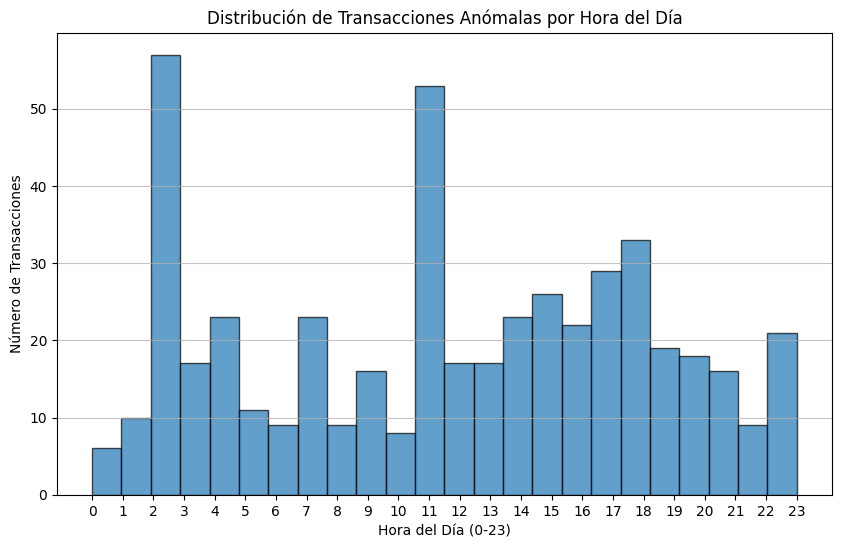

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(anomalies_time_complete_df, bins=24, edgecolor='black', alpha=0.7)

plt.title('Distribución de Transacciones Anómalas por Hora del Día')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Número de Transacciones')
plt.xticks(range(0, 24))

plt.grid(axis='y', alpha=0.75)
plt.show()

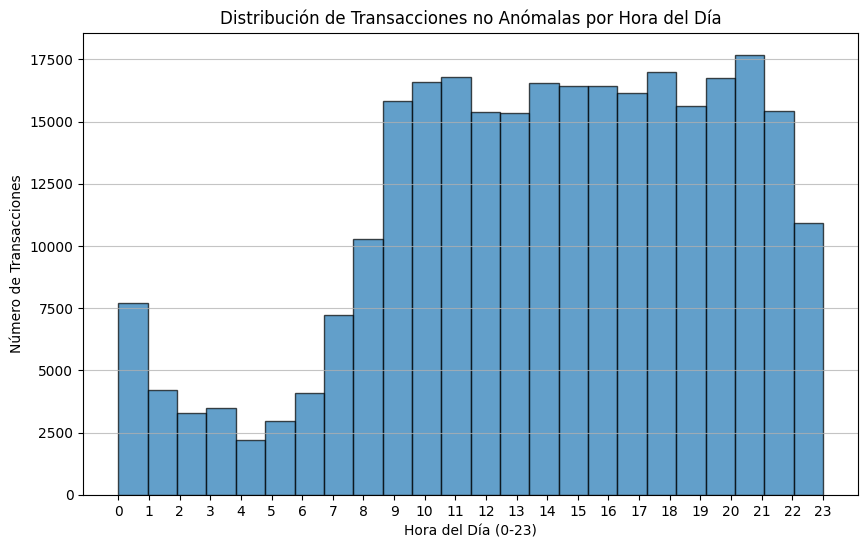

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(non_anomalies_time_complete_df, bins=24, edgecolor='black', alpha=0.7)

plt.title('Distribución de Transacciones no Anómalas por Hora del Día')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Número de Transacciones')
plt.xticks(range(0, 24))

plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
from contextlib import AbstractAsyncContextManager
hour_groups = dict()
for i in range(0, 24):
  hour_groups[i] = {
      "anomalies": anomalies_time_complete_df[anomalies_time_complete_df == i].count().item(),
      "non_anomalies": non_anomalies_time_complete_df[non_anomalies_time_complete_df == i].count().item()
  }

In [ ]:
for hour, counts in hour_groups.items():
  anomalies_count = counts['anomalies']
  non_anomalies_count = counts['non_anomalies']
  total_count = anomalies_count + non_anomalies_count
  print("Hora {}: {} anomalias ({:.4f} % total anomalo) / {} no anomalias ({:.4f} % total no anomalo) / relacion anomalias - total hora {}/{} ({:.4f} %)".format(
            hour,
            anomalies_count, (anomalies_count * 100 / len(anomalies_time_complete_df)),
            non_anomalies_count, (non_anomalies_count * 100 / len(non_anomalies_time_complete_df)),
            anomalies_count, non_anomalies_count, (anomalies_count * 100 / total_count)))

Hora 0: 6 anomalias (1.2195 % total anomalo) / 7689 no anomalias (2.7044 % total no anomalo) / relacion anomalias - total hora 6/7689 (0.0780 %)
Hora 1: 10 anomalias (2.0325 % total anomalo) / 4210 no anomalias (1.4808 % total no anomalo) / relacion anomalias - total hora 10/4210 (0.2370 %)
Hora 2: 57 anomalias (11.5854 % total anomalo) / 3271 no anomalias (1.1505 % total no anomalo) / relacion anomalias - total hora 57/3271 (1.7127 %)
Hora 3: 17 anomalias (3.4553 % total anomalo) / 3475 no anomalias (1.2222 % total no anomalo) / relacion anomalias - total hora 17/3475 (0.4868 %)
Hora 4: 23 anomalias (4.6748 % total anomalo) / 2186 no anomalias (0.7689 % total no anomalo) / relacion anomalias - total hora 23/2186 (1.0412 %)
Hora 5: 11 anomalias (2.2358 % total anomalo) / 2979 no anomalias (1.0478 % total no anomalo) / relacion anomalias - total hora 11/2979 (0.3679 %)
Hora 6: 9 anomalias (1.8293 % total anomalo) / 4092 no anomalias (1.4392 % total no anomalo) / relacion anomalias - tot

#Entrenamiento y metricas

- Durante el entrenamiento, se utiliza un pipeline que recibe un ColumnTransformer para aplicar un One Hot Encoding sobre la columna de tiempo con las entradas ya codificadas como horas y el modelo correspondiente en cada caso. Debido a la pequeña cantidad de muestras anómalas se trabaja únicamente con conjunto de entrenamiento y validación y no con testing (para no quitarle muestras anómalas al conjunto de validación y poder comparar los modelos con mayor criterio). Al tratarse de un problema de detección de anomalías, todos los datos de entrenamiento corresponden a muestras no anómalas, puesto que el objetivo es detectar casos que escapan a la normalidad de los datos.
- Un aspecto relevante a tener en cuenta es que el foco a la hora de comparar los modelos, se centró en la métrica de F1-score (media armónica entre Precision y Recall), y en la de Recall o también conocida como Sensitivity (proporción de muestras positivas detectadas correctamente). Esto se debe a que dadas las características del problema y del elevado sesgo de clases que este presenta, resulta fundamental poder detectar correctamente las anomalías, ya que cada transacción anómala que no se detecte realmente como tal, puede implicar un alto costo. Y en general la Precision (que mide la proporción de muestras positivas detectadas correctamente entre todas las muestras detectadas como positivas) suele ser extremadamente alta en el problema y muy similar para la mayoría de los modelos, lo que implica que encontrar un mejor Recall en general lleva a encontrar un mejor F1-score. Desde ya no se le dio tanta importancia a la Precision (únicamente si fuera un caso donde se empata en Recall y la precisión eleve el F1-score por ser un poco mejor, caso que no se dio). Una métrica directamente no considerada es la Specificity, ya que esta resultaría aun mas engañosa que la Precision para este problema, puesto que mide la proporción de casos negativos reales que el clasificador identifica correctamente como negativos, lo cual por lo ya explicado no es el foco en este caso y podría dar extremedamente alta en modelos con un desempeño bajo para la detección de anomalías. Y finalmente el Accuracy, que representa el porcentaje total de valores correctamente clasificados tanto positivos como negativos, tampoco se tomó en cuenta porque no aportaría mucho en este caso al tratarse de un problema con clases extremadamente sesgadas.
- También se aplicó un downsampling sobre los datos a modo de reducir la dimensionalidad del dataset de entrenamiento (ya que en particular para los modelos de LOF y One Class SVM que son más costosos, el tiempo era demasiado elevado), pero este se llevó a cabo solamente sobre las muestras no anómalas previo a separarlas en entrenamiento y validación. Esto es por dos motivos fundamentales, por un lado las muestras anómalas no se utilizan para el entrenamiento por lo que no tendría mucho sentido buscar reducir los datos de entrenamiento a partir de quitar anomalías. Y además, al tener tan pocas anomalías en el dataset, resulta fundamental conservarlas todas para las validaciones de los entrenamientos, y así poder comparar los modelos con mayor criterio.

In [ ]:
def get_features_and_target(dataset):

  # -------------------------------- SEPARACIÓN EN FEATURES Y TARGET --------------------------------

  dataset_copy = dataset.copy() # generalmente pandas hace una copia profunda, pero en algunos casos puede ocurrir que haga una copia perezosa, por las dudas se hace así
  X = dataset_copy.drop(columns='Class') # features
  y = dataset_copy['Class'] # target
  y = y.replace({1: -1, 0: 1}) # acomodamos las clases para alinearlas como las trata sklearn

  return X, y

def get_pipeline(model):

  preprocessor = ColumnTransformer([
      ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'), ['Time']),
      ('scaler', StandardScaler(), ['Amount'])], remainder="passthrough")

  # -------------------------------- PIPELINE GENERAL DE PREPROCESAMIENTO Y ENTRENAMIENTO --------------------------------

  return Pipeline([
    ('preprocessor', preprocessor),
    ('anomaly_detector', model)])

def split_dataset(X, y): # no se utiliza un conjunto de test ya que hay pocas muestras y es preferible usar todas las anómalas para validación y así comparar con mayor criterio los modelos

  anomalies_mask = (y == -1)

  # se obtienen todas las muestras anomalas del dataset, de las
  # cuales todas van a ir para validacion (porque no se entrena con anomalos)
  X_anomalies = X[anomalies_mask]
  y_anomalies = y[anomalies_mask]

  # se obtienen todas las muestras no anomalas del dataset
  X_non_anomalies = X[~anomalies_mask]
  y_non_anomalies = y[~anomalies_mask]

  # una vez que ya se tienen las muestras no anomalas separadas, se aplica un downsampling sobre el conjunto de las mismas ya que sino es
  # demasiado grande, y los algoritmos de LOF y One Class SVM tardan mucho durante el fit, y de esta manera no se hace downsampling
  # sobre los datos no anómalos, que se conservan completamente
  non_anomalies_df = pd.concat([X_non_anomalies, y_non_anomalies], axis=1)
  non_anomalies_df = non_anomalies_df.sample(n=5000, random_state=42)
  X_non_anomalies = non_anomalies_df.drop(columns='Class')
  y_non_anomalies = non_anomalies_df['Class']

  # se separan efectivamente las muestras no anomalas del dataset, de las cuales se usa el 10% para validacion y el restante
  # 90 % representa el conjunto de entrenamiento completo (puesto que en detección de anomalías se entrena solo con muestras no anómalas)
  X_train, X_non_anomalies_val, y_train, y_non_anomalies_val = train_test_split(
      X_non_anomalies,
      y_non_anomalies,
      test_size=0.1,
      random_state=10,
      shuffle=True
  )

  # se combinan las muestras anomalas y no anomalas de validacion para obtener el conjunto de validacion completo
  X_val = pd.concat([X_anomalies, X_non_anomalies_val], axis=0)
  y_val = pd.concat([y_anomalies, y_non_anomalies_val], axis=0)


  return X_train, X_val, y_train, y_val # en general el y_train no tiene mucho sentido y no se la da uso porque se trata de un problema no supervisado

  # -------------------------------- ENTRENAMIENTO Y PREDICCIÓN SIMPLE --------------------------------

def simple_training_and_prediction(model, thresholds=None): # este metodo permite pasarle un conjunto de predicciones y un conjunto de umbrales y obtener el conjunto de predicciones para cada umbral
  X, y = get_features_and_target(credit_card_df)
  general_pipeline = get_pipeline(model)
  X_train, X_val, y_train, y_val = split_dataset(X, y)

  general_pipeline.fit(X_train, y_train) # aunque se pasa el y_train en general no se usa y no aporta nada, puesto que dos de los modelos son no supervisados y en caso del Isolation Forest que puede entrenarse supervisada o no supervisadamente no tiene impacto esto ya que no se utilizan muestras anómalas para entrenar

  threshold_results = dict()
  if not thresholds:
    thresholds = [0]

  X_val_transformed = general_pipeline.named_steps['preprocessor'].transform(X_val) # se hace asi ya que en caso de querer usar thresholds especificos, no se debe llamar al predict que usa internamente 0
  scores = general_pipeline.named_steps['anomaly_detector'].decision_function(X_val_transformed)
  for thresh in thresholds:
    y_pred = np.where(scores < thresh, -1, 1)
    threshold_results[thresh] = {
        'pred': y_pred,
        'y_val': y_val
    }

  return {
      'threshold_results': threshold_results,
      'scores': scores
  }


  # -------------------------------- EVALUACIÓN --------------------------------

def get_metrics_for_model(y_test, y_pred, classes):
  #ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize=None, display_labels=classes, cmap=plt.cm.Blues) # matriz de confusión de las predicciones para conocer los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos de la predicción
  return f1s(y_test, y_pred, pos_label=-1), ps(y_test, y_pred, pos_label=-1), rs(y_test, y_pred, pos_label=-1)
  # F1-score = 2 * (Precision * Recall) / (Precision + Recall)
  # Precision = TP / (TP + FP)
  # Recall = TP / (TP + FN)

## Validamos distribución de anomalías


In [ ]:
X, y = get_features_and_target(credit_card_df)
X_train, X_val, y_train, y_val = split_dataset(X, y)

train_anomalies = y_train[y_train == -1].count()
val_anomalies = np.sum(y_val == -1)

In [ ]:
print(f"Training set -> Total de muestras: {len(y_train)} - Total de anomalias: {train_anomalies} - Porcentaje de anomalias: ({train_anomalies * 100 / len(y_train):.4f} %)")

print(f"Validation set -> Total de muestras: {len(y_val)} - Total de anomalias: {val_anomalies} - Porcentaje de anomalias: ({val_anomalies * 100 / len(y_val):.4f} %)")

Training set -> Total de muestras: 4500 - Total de anomalias: 0 - Porcentaje de anomalias: (0.0000 %)
Validation set -> Total de muestras: 992 - Total de anomalias: 492 - Porcentaje de anomalias: (49.5968 %)


## Isolation Forest
Elegimos Isolation Forest como uno de los modelos para la resolución de este problema debido a (1) su buen rendimiento, (2) su resistencia ante features irrelevantes, y (3) la premisa de la que parte: las anomalías suelen ser **pocas** y diferenciables.

Cabe aclarar que si bien este modelo a diferencia de los otros dos podría entrenarse de manera supervisada utilizando muestras anómalas también, no se hace esto a fin de poder comparar los modelos entrenando con exactamente los mismos datos, lo que resulta más justo a la hora de las comparaciones.

In [ ]:
number_of_trees = [5, 20, 60, 80, 100, 150, 200, 300, 400]
training_results = []
thresholds = None
for n in number_of_trees:
  training_results.append(simple_training_and_prediction(model=IsolationForest(n_estimators=n, random_state=42), thresholds=thresholds))

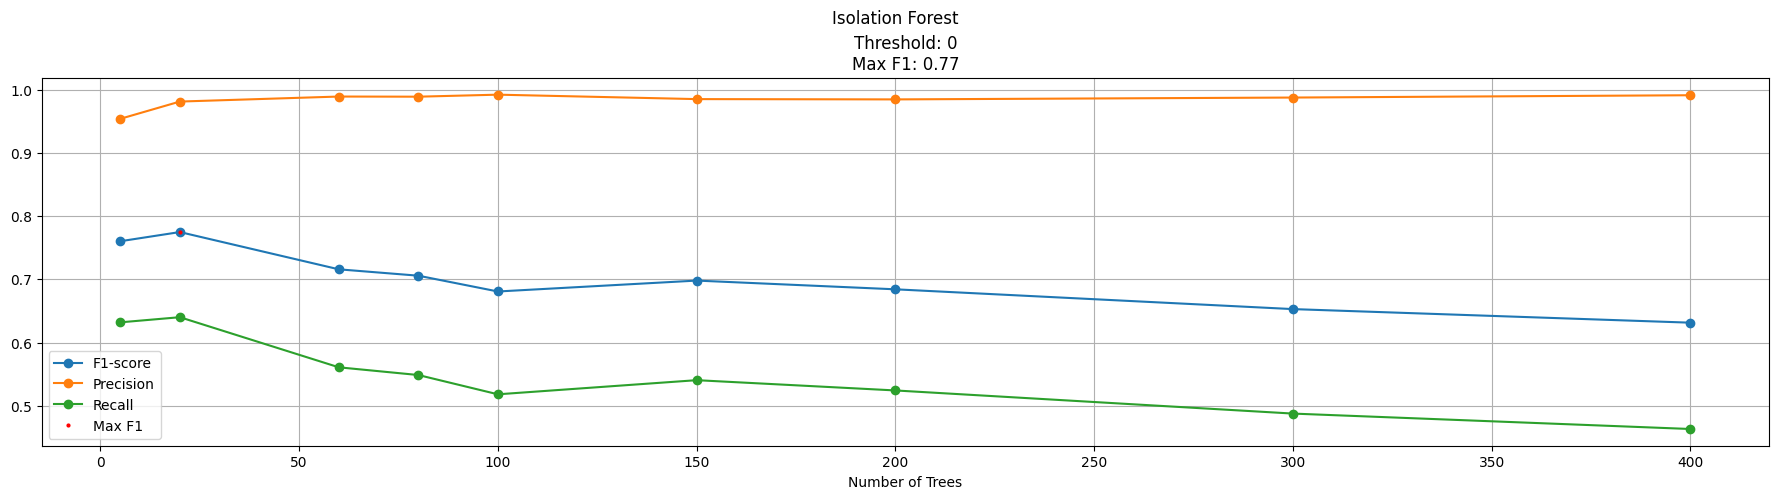

In [ ]:
if not thresholds:
  thresholds = [0]

f1_scores = {thresh: [] for thresh in thresholds}
precision_scores = {thresh: [] for thresh in thresholds}
recall_scores = {thresh: [] for thresh in thresholds}
for values in training_results:
  threhsold_results = values['threshold_results']
  for thresh, results in threhsold_results.items():
    f1_score_n, precision_score_n, recall_score_n = get_metrics_for_model(results['y_val'], results['pred'], classes=['-1', '1'])
    f1_scores[thresh].append(f1_score_n)
    precision_scores[thresh].append(precision_score_n)
    recall_scores[thresh].append(recall_score_n)

isolation_forest_f1 = np.max([np.max(scores) for scores in f1_scores.values()])

# Plotting
fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 5), sharey=True)
fig.suptitle('Isolation Forest')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

if len(thresholds) == 1:
    axes = [axes]

for i, thresh in enumerate(thresholds):

    max_f1 = np.max(f1_scores[thresh])
    max_f1_idx = np.argmax(f1_scores[thresh])
    max_f1_trees = number_of_trees[max_f1_idx]

    ax = axes[i]
    ax.plot(number_of_trees, f1_scores[thresh], '-o', label='F1-score')
    ax.plot(number_of_trees, precision_scores[thresh], '-o', label='Precision')
    ax.plot(number_of_trees, recall_scores[thresh], '-o', label='Recall')
    ax.plot(max_f1_trees, max_f1, 'o', color='red', markersize=2, label='Max F1')

    ax.set_title(f'Threshold: {thresh}\nMax F1: {max_f1:.2f}')
    ax.set_xlabel('Number of Trees')
    ax.legend()
    ax.grid(True)

plt.show()

El gráfico generado deja ver que, para este problema, Isolation Forest obtuvo mejores resultados con n (número de estimadores) = 20, logrando un **F1-score** de **0.77**. También se destaca que, a medida que el número de estimadores fue incrementando, el rendimiento del modelo fue decayendo.

## Local outlier factor

Utilizamos el algoritmo Local Outlier Factor (LOF) para la detección de anomalías, evaluando su desempeño bajo diferentes configuraciones. LOF es un algoritmo no supervisado que nos permite calcular que tan aislado está un punto respecto a sus vecinos cercanos. Cuanto mayor sea su aislamiento mayor es la probabilidad de que ese punto sea un outlier (el score LOF es más bajo).

Como estamos utilizando la técnica en modo novelty=True, entrenamos únicamente con instancias normales.Luego evaluamos con datos que sí contienen anomalías.

In [ ]:
# Definimos hiperparámetros a comparar
number_of_neighbors = [1, 3, 5, 10, 15]
thresholds = [-0.7, -0.9, -1, -1.2, -1.5, -2.0]

# Ejecutamos el modelo y guardámos predicciones
training_results = []
for n in number_of_neighbors:
  training_results.append(simple_training_and_prediction(model=LocalOutlierFactor(n_neighbors=n, novelty=True, n_jobs=-1), thresholds=thresholds))

### Analizando resultados

Durante la evaluación, se probaron distintas configuraciones variando tanto la cantidad de vecinos (k) como el umbral de decisión. Este umbral define cuán bajo debe ser el score LOF para considerar a una observación como anómala. A medida que el umbral se reduce (es decir, nos volvemos más estrictos), se identifican menos puntos como outliers, ya que ahora se requiere que estén más alejados de su entorno para ser clasificados como tales.

Esta variación se refleja en las métricas: cuando el umbral disminuye, la recall tiende a bajar, ya que se detectan menos verdaderos positivos (menos anomalías reales son identificadas correctamente). Por otro lado, la precisión aumenta, ya que el modelo se vuelve más conservador y, por ende, comete menos falsos positivos, mejorando el ratio entre verdaderos positivos y todos los elementos clasificados como outliers.

En cuanto al número de vecinos (k), se observa que, para umbrales bajos, un valor más alto de k suele mejorar la recall. Esto indica que tener en cuenta un contexto más amplio (más vecinos) permite al modelo detectar más casos de anomalías reales, lo cual puede ser valioso si el objetivo es maximizar la detección, aunque implique un leve aumento de falsos positivos.

Finalmente, la mejor configuración observada en términos de F1-score (equilibrio entre precisión y recall) fue con 15 vecinos y un umbral de -0.7.

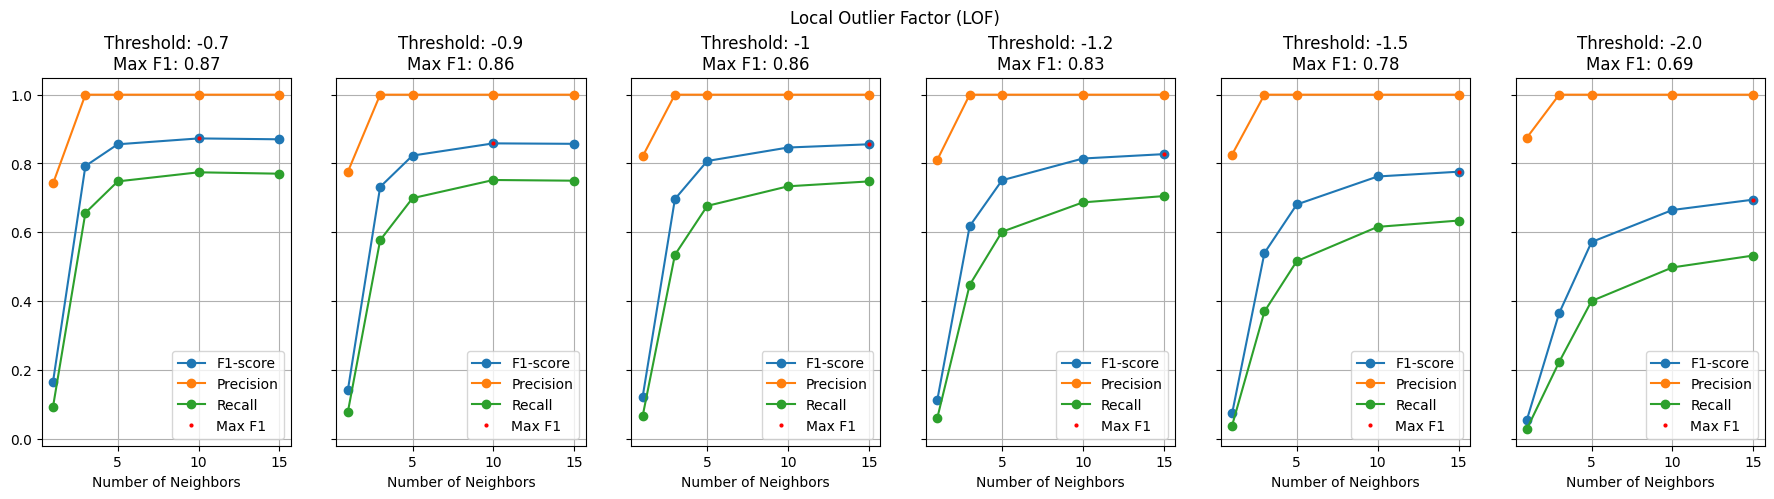

In [ ]:
if not thresholds:
  thresholds = [0]

f1_scores = {thresh: [] for thresh in thresholds}
precision_scores = {thresh: [] for thresh in thresholds}
recall_scores = {thresh: [] for thresh in thresholds}
for values in training_results:
  threhsold_results = values['threshold_results']
  for thresh, results in threhsold_results.items():
    f1_score_n, precision_score_n, recall_score_n = get_metrics_for_model(results['y_val'], results['pred'], classes=['-1', '1'])
    f1_scores[thresh].append(f1_score_n)
    precision_scores[thresh].append(precision_score_n)
    recall_scores[thresh].append(recall_score_n)

local_outlier_factor_f1 = np.max([np.max(scores) for scores in f1_scores.values()])

# Plotting
fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 5), sharey=True)
fig.suptitle('Local Outlier Factor (LOF)')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

if len(thresholds) == 1:
    axes = [axes]

for i, thresh in enumerate(thresholds):

    max_f1 = np.max(f1_scores[thresh])
    max_f1_idx = np.argmax(f1_scores[thresh])
    max_f1_neighbors = number_of_neighbors[max_f1_idx]

    ax = axes[i]
    ax.plot(number_of_neighbors, f1_scores[thresh], '-o', label='F1-score')
    ax.plot(number_of_neighbors, precision_scores[thresh], '-o', label='Precision')
    ax.plot(number_of_neighbors, recall_scores[thresh], '-o', label='Recall')
    ax.plot(max_f1_neighbors, max_f1, 'o', color='red', markersize=2, label='Max F1')

    ax.set_title(f'Threshold: {thresh}\nMax F1: {max_f1:.2f}')
    ax.set_xlabel('Number of Neighbors')
    ax.legend()
    ax.grid(True)

plt.show()

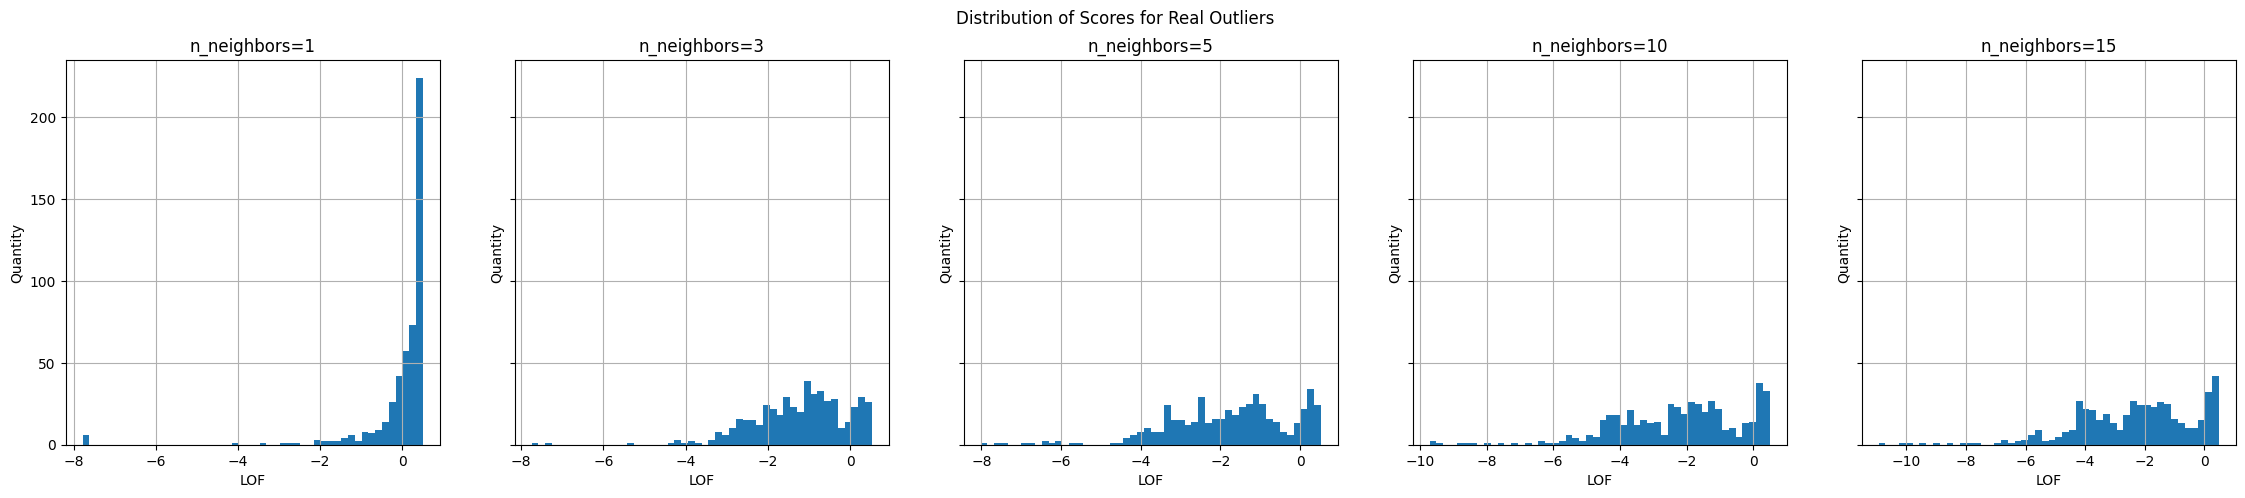

In [ ]:
# hacemos un plot de la distribución de la cantidad de outliers por rango de LOF
# según la cantidad de k vecinos.
#   Vemos que con 1 vecino la mayoría de los outliers tienen un LOF > -1
#     por ende el recall caería demasiado ya que no se detectan.

fig, axes = plt.subplots(1, len(number_of_neighbors), figsize=(28, 5), sharey=True)
fig.suptitle('Distribution of Scores for Real Outliers')

for i, n in enumerate(number_of_neighbors):
    scores = training_results[i]['scores']
    outlier_scores = scores[y_val == -1]

    ax = axes[i]
    ax.hist(outlier_scores, bins=50)
    ax.set_title(f"n_neighbors={n}")
    ax.set_xlabel('LOF')
    ax.set_ylabel("Quantity")
    ax.grid(True)

plt.show()

## 1-Class SVM
Además de los dos modelos previos, quisimos probar también 1-Class SVM ya que, según lo visto en la teoría, es un modelo que funciona muy bien para detección de anomalías. Los valores de ν (nu) se definieron en torno al porcentaje de anomalías del conjunto de datos.\
Adicionalmente, en este caso aplicamos GridSearchCV para encontrar la combinación óptima de hiperparámetros para el modelo, incluyendo en las pruebas distintos kernels.

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
import numpy as np

# Obtenemos los datos
X, y = get_features_and_target(credit_card_df)
X_train, X_val, y_train, y_val = split_dataset(X, y)

# Calculamos el porcentaje de anomalías en el dataset
total_anomalies = np.sum(y == -1)
total_samples = len(y)
anomalies_percentage = total_anomalies / total_samples  # proporción, no en %

# Definimos los valores de hiperparámetros
gamma_values = list(2.0 ** np.arange(-10, 0))            # Distintos valores para γ (gamma)
kernel_values = ('rbf', 'poly', 'sigmoid')               # Kernels que usan gamma
nu_values = [
    anomalies_percentage / 4,
    anomalies_percentage / 2,
    anomalies_percentage,
    anomalies_percentage * 2,
    anomalies_percentage * 4,
]

# Definimos el estimador base
svm_estimator = OneClassSVM()

# Creamos la grilla de hiperparámetros
param_grid = {
    'kernel': kernel_values,
    'gamma': gamma_values,
    'nu': nu_values
}

# Definimos la búsqueda con validación cruzada (cv=3)
svm_grid = GridSearchCV(
    estimator=svm_estimator,
    param_grid=param_grid,
    cv=3,
    scoring=make_scorer(f1_score, pos_label=-1), #creamos un f1-score con la clase anómala
    n_jobs=-1
)

# Entrenamos el modelo usando la grilla de búsqueda
svm_grid.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(svm_grid.best_params_)

print("\nMejor modelo (OneClassSVM):")
print(svm_grid.best_estimator_)



Mejores hiperparámetros encontrados:
{'gamma': np.float64(0.0009765625), 'kernel': 'rbf', 'nu': np.float64(0.0004318714076550085)}

Mejor modelo (OneClassSVM):
OneClassSVM(gamma=np.float64(0.0009765625),
            nu=np.float64(0.0004318714076550085))


GridSearchCV nos indica que, para este problema, la combinación óptima de hiperparámetros es γ (gamma) = 0.0009765625, kernel RBF, y ν (nu) = 0.0004318714076550085. A continuación, calculamos las métricas para 1-Class SVM usando esta configuración:


✅ OneClassSVM con configuración óptima {'gamma': np.float64(0.0009765625), 'kernel': 'rbf', 'nu': np.float64(0.0004318714076550085)} obtiene un F1-score de 0.7981 en el conjunto de validación.


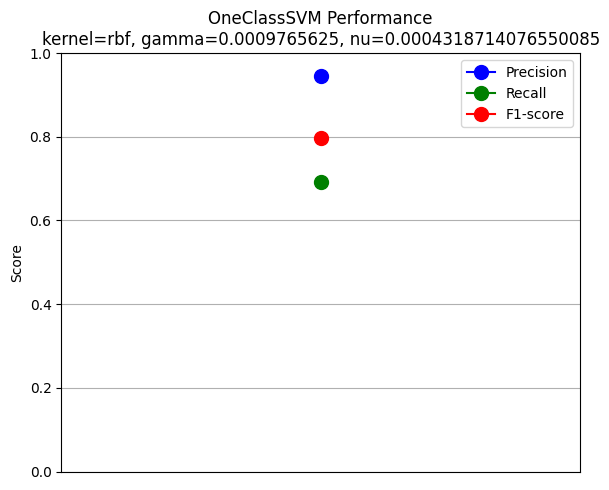

In [ ]:
# Evaluamos en el conjunto de validación con el mejor modelo
best_model = svm_grid.best_estimator_
y_pred = best_model.predict(X_val)

#ploteamos las métricas del mejor modelo
one_class_f1, precision, recall = get_metrics_for_model(y_val, y_pred, classes=['-1', '1'])

# Mostramos resultado final
print(f"\n✅ OneClassSVM con configuración óptima {svm_grid.best_params_} obtiene un F1-score de {one_class_f1:.4f} en el conjunto de validación.")

# Crear el gráfico
plt.figure(figsize=(6, 5))
plt.ylim(0, 1)
plt.plot(0, precision, "-ob", label="Precision",markersize=10)
plt.plot(0, recall, "-og", label="Recall",markersize=10)
plt.plot(0, one_class_f1, "-or", label="F1-score",markersize=10)
plt.ylabel("Score")
title_str = (
    f"OneClassSVM Performance\n"
    f"kernel={svm_grid.best_params_['kernel']}, gamma={svm_grid.best_params_['gamma']}, nu={svm_grid.best_params_['nu']}"
)
plt.title(title_str)
plt.xticks([])
plt.grid(axis='y')
plt.tight_layout()
plt.legend()
plt.show()

En el gráfico se puede observar que, con la configuración óptima, 1-Class SVM logró un **F1-score** de **0.79**. Si bien es un buen puntaje, LOF permanece como el modelo que mejores resultados consiguió para este problema de detección de anomalías.

In [ ]:
# el mejor algoritmo es....

best_f1 = [isolation_forest_f1, local_outlier_factor_f1, one_class_f1]
f1_models_names = ['Isolation Forest', 'Local Outlier Factor', 'One Class SVM']
print(f"El mejor algoritmo para esta tarea es {f1_models_names[np.argmax(best_f1)]} con f1-score: {np.max(best_f1)}")



El mejor algoritmo para esta tarea es Local Outlier Factor con f1-score: 0.872852233676976
